## Data Update for 2025-10-21 export - Cleaning the Data

This file is to clean the New England Whalers data downloaded from the Whaling logbook database.

The main layout of this script is as follows:
1. Import the necessary packages and data, and drop any unnecessary columns and rows
2. Clean the dataset, as follows:
    - REMOVE DUPLICATE ENTRIES
    - STANDARDIZE COLUMNS WITH EXTRA TEXT AND MAPPING WIND TERMS TO BF SCALE
    - CATCH/CORRECT COORDINATE ERRORS
    - PLOTTING TRAJECTORIES TO CATCH MISSED ERRORS
    - EXPORT CLEANED DATASET

In [1]:
# Import
import numpy as np
import pandas as pd
# import xarray as xr
import matplotlib.pyplot as plt
import datetime, os
from cartopy import crs as ccrs
from cartopy import feature as cfeature
# import seaborn as sns 
# from tabulate import tabulate
import sys
import re
from IPython.display import clear_output
import datetime
import textwrap
import csv

pd.options.display.max_columns = 50

print("Last updated on {}".format(datetime.datetime.now().ctime()))

Last updated on Mon Dec 22 15:07:40 2025


In [2]:
# Setting up a folder system to save files and figures to 
# Create folders called "Figures", "Text Files", and "CSV Files" manually to save everything to 

# Get current directory
current_directory = os.getcwd()
#print(current_directory)

# Specify the path to the folder you want to save data to 
Figures = os.path.join(current_directory, 'figures')
Files = os.path.join(current_directory, 'output_txt_files')
CSV = os.path.join(current_directory, 'csv_files')
PKL = os.path.join(current_directory, "PKL")

#NOTE: copy and past permanent_txt_files from previous export

# Create directories only if they don't exist
os.makedirs(Figures, exist_ok=True)
os.makedirs(Files, exist_ok=True)
os.makedirs(CSV, exist_ok=True)

### Importing Logbook Dataset

In [3]:
# labels corresponding to missing data
na_values = ['No observation', 'No observations', 'No Observation', 'No Observations',
             'no observation', 'no observations', 'None given', 'none given', 'None Given', 'none',
             'none recorded', 'not recorded', 'None recorded', 'Not given', 'not given', ' ', 'N.A.', 
             'Na', 'Does not say', 'N.A', 'Deos not say', 'N A', 'NA']

#export_csv = 'logentries-export-2025-10-21.csv'
export_csv = 'logentries-export-2025-11-03.csv'

og_df = pd.read_csv(os.path.join(CSV, export_csv), na_values=na_values, low_memory=False)

# Combine using column names
og_df['DateTime'] = pd.to_datetime(og_df['Entry Date'] + ' ' + og_df['Local Time'], errors='coerce')
og_df.columns

Index(['ID', 'LogBook ID', 'Page', 'Entry Date', 'Local Time', 'Latitude',
       'Longitude', 'Depth', 'Depth Unit', 'Bottom', 'Current', 'Landmark',
       'Ship Heading/Course', 'Wind Direction', 'Wind Speed/Force',
       'Sea State', 'Cloud Cover', 'Weather', '2. Ship Heading/Course',
       '2. Wind Direction', '2. Wind Speed/Force', '2. Sea State',
       '2. Cloud Cover', '2. Weather', '3. Ship Heading', '3. Wind Direction',
       '3. Wind Speed/Force', '3. Sea State', '3. Cloud Cover', '3. Weather',
       'Ship Sightings', 'Instrumental Observations',
       'Miscellaneous Observations', 'DateTime'],
      dtype='object')

In [4]:
#OPTIONAL
# # Adding researchers to the df to look into how new entries are going
# researchers_df = pd.read_csv('researchers-export-2025-03-31.csv',
#                              na_values=na_values)

# # Merge on the 'ID' column, adding the 'researcher' column
# df = df.merge(researchers_df[['ID', 'Researcher', 'Published']], on='ID', how='left')

In [5]:
#OPTIONAL
#How many entries since last export?
#Need to update subtracted number every entry
#old_len = 'enter_int'
#print(f"There have been {len(df) - old_len} entries since the lasts export") #number given by last export summary

In [6]:
# #OPTIONAL
# # Finding how many times there is a wind force value in the second or third
# # observation but not first to see if we want to try and infill with these 

# # Create a dataframe when original wind speed/force observation is nan, but 2. and 3. are not nan
# df['wind force'] = (df["Wind Speed/Force"].isna() & (df["2. Wind Speed/Force"].notna() | df["3. Wind Speed/Force"].notna()))
# df_wf = df[df['wind force']==True]
# #df_wf

In [7]:
# Dropping columns not needed
columns_to_drop = ['Current', '2. Ship Heading/Course', '2. Wind Direction', '2. Wind Speed/Force', 
                   '2. Sea State', '2. Cloud Cover', '2. Weather', '3. Ship Heading', '3. Wind Direction', 
                   '3. Wind Speed/Force', '3. Sea State', '3. Cloud Cover', '3. Weather',
                   'Instrumental Observations']

# Drop the specified columns
trimmed_df = og_df.copy()
trimmed_df.drop(columns=columns_to_drop, inplace=True)

## Cleaning the Dataset

Dropping test entries and logbooks which need extensive corrections

In [9]:
#drop test logbooks and logbooks that need further in-person inspection
standard_drops = ['TEST LOG BOOK NAME', '55', 'Westward-1978', 'TEST TEST HG JULY 2025']
temp_drops = ['Alaska (Bark) 1880-1884', 'Mercator(Ship) 1840-1843','President (Bark) 1865-1869', 'Lancer (Ship) 1865-1868', 'Herald (Ship)  1834-1837',  'Lapwing (Ship) 1860-1863']

In [10]:
df1 = trimmed_df.copy()

#always run
for logbook in standard_drops:
    df1.drop(df1.loc[df1["LogBook ID"] == logbook].index,axis=0,inplace=True)

#run until logbooks have been fixed in the database
for logbook in temp_drops:
    df1.drop(df1.loc[df1["LogBook ID"] == logbook].index,axis=0,inplace=True)

DateTime formatting

In [11]:
# replace DateTime-strings that end with ' nan' with np.nan
df_dt = df1.copy()
df_dt.loc[df_dt.DateTime.astype(str).str.endswith(' nan'), 'DateTime'] = np.nan

In [12]:
# converting 'DateTime' column to actual DateTime and calling it "Entry Date Time"
df_dt['Entry Date Time'] = pd.to_datetime(df_dt.DateTime, format = '%Y-%m-%d %H:%M:%S')
# deleting row "DateTime"
df_dt.drop('DateTime',axis=1)

,ID,LogBook ID,Page,Entry Date,Local Time,Latitude,Longitude,Depth,Depth Unit,Bottom,Landmark,Ship Heading/Course,Wind Direction,Wind Speed/Force,Sea State,Cloud Cover,Weather,Ship Sightings,Miscellaneous Observations,Entry Date Time
0,137052,Amethyst (Ship) 1838-1840,99,1839-12-11,12:00:00,49 35 S,104 00 E,NaN,NaN,NaN,NaN,NaN,NaN,fresh breezes,NaN,NaN,squally,NaN,NaN,1839-12-11 12:00:00
1,137051,Amethyst (Ship) 1838-1840,99,1839-12-10,12:00:00,48 34 S,113 05 E,NaN,NaN,NaN,NaN,NaN,NaN,brisk winds,NaN,NaN,fair,NaN,NaN,1839-12-10 12:00:00
2,137050,Amethyst (Ship) 1838-1840,98,1839-12-09,12:00:00,47 39 S,NaN,NaN,NaN,NaN,NaN,NaN,NaN,brisk winds,NaN,NaN,fair,NaN,NaN,1839-12-09 12:00:00
3,137049,Amethyst (Ship) 1838-1840,98,1839-12-08,12:00:00,47 15 S,121 36 E,NaN,NaN,NaN,NaN,NaN,NaN,strong winds,NaN,NaN,overcast,NaN,NaN,1839-12-08 12:00:00
4,137048,Amethyst (Ship) 1838-1840,97,1839-12-07,12:00:00,46 34 S,NaN,NaN,NaN,NaN,NaN,NaN,NaN,strong winds,NaN,NaN,fair,NaN,NaN,1839-12-07 12:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
132976,520,Alpha (ship) 1855-1859,26,1855-11-06,12:00:00,40 07 S,39 02 E,NaN,Fathoms,NaN,NaN,SE by E,From N NW,Moderate Gale,NaN,NaN,Squally,NaN,"""Under fore and main topsail and foresail, miz...",1855-11-06 12:00:00
132977,519,Alpha (ship) 1855-1859,26,1855-11-05,12:00:00,39 59 S,28 09 E,NaN,Fathoms,NaN,NaN,"""Middle moderate""",From N NW,Strong Breeze and Squally Wind,NaN,NaN,NaN,NaN,"""Took in Fore and Main topgallant sails""",1855-11-05 12:00:00
132978,518,Alpha (ship) 1855-1859,26,1855-11-04,12:00:00,40 23 S,23 37 E,NaN,Fathoms,NaN,NaN,SE by E,From N NW,Strong Breeze,NaN,NaN,NaN,NaN,"""Under double-reefed topsails""",1855-11-04 12:00:00
132979,517,Alpha (ship) 1855-1859,26,1855-11-03,12:00:00,40 05 S,19 43 E,NaN,Fathoms,NaN,NaN,SE by S,From W by S,Strong Breeze,NaN,NaN,NaN,NaN,"""Furled the mainsail and jib""",1855-11-03 12:00:00


## Removing repeated data

We have a few ships with multiple logbooks as well as duplicate entries that have verified as intentional (crossing the meridian, noting specific weather, etc.). Here we keep a running list of these so that we only flag new duplicate entries with each new export.  

In [13]:
df_no_known_dups = df_dt.copy()

# Removing potential duplicates of data from the Leonidas ships
# Filter rows corresponding to "Leonidas (ship) Journal 1830-1833" and "Leonidas (ship) 1830-1833"
leonidas_journal_rows = df_no_known_dups[df_no_known_dups['LogBook ID'] == 'Leonidas (ship) Journal 1830-1…']
leonidas_rows = df_no_known_dups[df_no_known_dups['LogBook ID'] == 'Leonidas (ship) 1830-1833']

# Get the 'Entry Date Time' values from "Leonidas (ship) Journal 1830-1833"
journal_entry_times = leonidas_journal_rows['Entry Date Time']

# Find indices of rows from "Leonidas (ship) Journal 1830-1833" that have the same 'Entry Date Time' values as in "Leonidas (ship) 1830-1833"
indices_to_drop = leonidas_journal_rows[leonidas_journal_rows['Entry Date Time'].isin(leonidas_rows['Entry Date Time'])].index

# Drop the "Leonidas (ship) Journal 1830-1833" rows from the original DataFrame
df_no_known_dups = df_no_known_dups.drop(indices_to_drop)

In [14]:
# Removing potential duplicates of data from the Margaret ships

# Filter rows corresponding to "Margaret (ship) 1835-1836"
margaret_1835_1836_rows = df_no_known_dups[df_no_known_dups['LogBook ID'] == 'Margaret (ship) 1835-1836']

# Drop rows corresponding to "Margaret (ship) 1835-1836"
df_no_known_dups = df_no_known_dups.drop(margaret_1835_1836_rows.index)

# Filter rows corresponding to "Margaret (ship) 1835-1838" and "Margaret (Ship) 1835–1838"
margaret_ship_1835_1838_rows = df_no_known_dups[df_no_known_dups['LogBook ID'] == 'Margaret (ship) 1835-1838']
margaret_Ship_1835_1838_rows = df_no_known_dups[df_no_known_dups['LogBook ID'] == 'Margaret (Ship) 1835–1838']

# Find indices of rows from "Margaret (ship) 1835-1838" that have the same 'Entry Date Time' values as in "Margaret (Ship) 1835–1838"
indices_to_drop = margaret_ship_1835_1838_rows[margaret_ship_1835_1838_rows['Entry Date Time'].isin(margaret_Ship_1835_1838_rows['Entry Date Time'])].index

# Drop the rows from "Margaret (ship) 1835-1838" that have the same 'Entry Date Time' value as "Margaret (Ship) 1835–1838"
df_no_known_dups = df_no_known_dups.drop(indices_to_drop)

# Rename remaining entries from 'Margaret (ship) 1835-1838' to match 'Margaret (Ship) 1835-1838'
df_no_known_dups['LogBook ID'] = df_no_known_dups['LogBook ID'].replace('Margaret (ship) 1835-1838', 'Margaret (Ship) 1835-1838')
#df

# This should get rid of all entries from Margaret 1835-1836 and then keep rows from
# Margaret (ship) where there are dates missing for Margaret (Ship) and delete the rest

### Double Dates

In [15]:
#Reading in ok duplicate entries file:
ok_dups = os.path.join(current_directory, 'permanent_txt_files/ok_duplicate_dates.txt')
ok_df = pd.read_csv(ok_dups, sep="\t")
ok_df['Date'] = pd.to_datetime(ok_df['Date']).dt.date  # ensure 'Date' column is datetime.date objects
ok_set = set(zip(ok_df['LogBook ID'], ok_df['Date']))  # create lookup set

In [16]:
#Inspect dates that are indentical in same logbooks
#ie the date was entered incorrectly such that we have entries for 1/1/, 1/2, 1/2, 1/4
#or same day mistakenly entered 2x

df = df_no_known_dups.copy()

grp_cols = ['LogBook ID', 'Entry Date']
groups = df.groupby(grp_cols, dropna=False)
duplicate_date_groups = groups.filter(lambda group: len(group) > 1)

# Collect duplicate ID pairs
duplicate_pairs = []

# Group and check for new duplicates
for (logbook_id, date), group in duplicate_date_groups.groupby(['LogBook ID', duplicate_date_groups['Entry Date Time'].dt.date]):
    
    # SKIP if this duplicate is already approved
    if (logbook_id, date) in ok_set:
        continue

    ids = group['ID'].unique()
    if len(ids) == 2:  # Only include clean duplicates (exactly 2 entries)
        duplicate_pairs.append(list(ids))
        print(f"Date: {date}, LogBook ID: {logbook_id}, IDs: {ids}")
    else:
        print(f" Skipping group with {len(ids)} entries on {date} ({logbook_id})")

print(f"Total duplicate pairs found: {len(duplicate_pairs)}")

Date: 1843-03-13, LogBook ID: Hibernia (Ship) 1842-1844, IDs: [136934 136933]
Date: 1840-01-14, LogBook ID: Jasper (ship) 1839-1841, IDs: [132553 129689]
Date: 1840-01-15, LogBook ID: Jasper (ship) 1839-1841, IDs: [132554 129690]
Date: 1840-01-16, LogBook ID: Jasper (ship) 1839-1841, IDs: [132555 129691]
Date: 1840-01-17, LogBook ID: Jasper (ship) 1839-1841, IDs: [132556 129692]
Date: 1840-01-18, LogBook ID: Jasper (ship) 1839-1841, IDs: [132557 129693]
Date: 1840-01-19, LogBook ID: Jasper (ship) 1839-1841, IDs: [132558 129694]
Date: 1840-01-20, LogBook ID: Jasper (ship) 1839-1841, IDs: [132559 129972]
Date: 1840-01-21, LogBook ID: Jasper (ship) 1839-1841, IDs: [132560 129973]
Date: 1840-01-22, LogBook ID: Jasper (ship) 1839-1841, IDs: [132561 129974]
Date: 1840-01-23, LogBook ID: Jasper (ship) 1839-1841, IDs: [132562 129975]
Date: 1840-01-24, LogBook ID: Jasper (ship) 1839-1841, IDs: [132563 129976]
Date: 1840-01-25, LogBook ID: Jasper (ship) 1839-1841, IDs: [132564 129977]
Date: 1868

#### New duplicates examined and fixed:

In [ ]:
# Define log file location
log_file = "duplicate_corrections_log.txt"
log_path = os.path.join(Files, log_file)

# Reset log at start
with open(log_path, "w") as f:
    f.write("=== Log Start ===\n")

In [ ]:
from utils.cleaning import correct_dups

for i, pair in enumerate(duplicate_pairs, 1):
    clear_output(wait=True)
    print(f"Reviewing {i} of {len(duplicate_pairs)}: IDs {pair}")
    df = correct_dups(df, pair, log_path=log_path)

In [ ]:
# saving corrected df so we dont have to do that again.
outpath = os.path.join(CSV, "logbook_no_dupes.csv")
df.to_csv(outpath, index=False, encoding="utf-8", quoting=csv.QUOTE_ALL)

### Cleaning page, depth, and ship sightings columns

In [ ]:
import os, pandas as pd, numpy as np
current_directory = os.getcwd()
CSV = os.path.join(current_directory, 'csv_files')
perm_txt = os.path.join(current_directory, 'permanent_txt_files')
out_txt = os.path.join(current_directory, 'output_txt_files')

df_path = os.path.join(CSV, "logbook_no_dupes.csv")
df1 = pd.read_csv(df_path)

In [ ]:
#Revised version that avoids deprecation:
# Strip strings and store
page_stripped = df1['Page'].astype(str).str.strip()

# Remove brackets based on condition
df1.loc[page_stripped.str.startswith('('), 'Page'] = page_stripped.str[1:4]
df1.loc[page_stripped.str.endswith(')'), 'Page'] = page_stripped.str[0:1]

In [ ]:
#Revised future-proofed version
with pd.option_context('display.max_rows', None):
    page_stripped = df1['Page'].astype(str).str.strip()

In [ ]:
from utils.cleaning import clean_page_column

temp_df = df1.copy()
df_page_cleaned = clean_page_column(temp_df, column='Page')

In [ ]:
from utils.cleaning import clean_depth_column

temp_df = df1.copy()
df_dep_cleaned = clean_depth_column(temp_df, column='Depth')

Handling common strings that should be set to NaN for other columns:

In [ ]:
#New df to continue cleaning
df2 = df_dep_cleaned.copy()
keywords = ['none', 'nnone', 'not recorded', 'Not Given']

for vname in ['Ship Heading/Course', 'Wind Direction', 'Wind Speed/Force']:
    # Convert to string to handle NaNs safely
    col = df2[vname].astype(str).str.strip()

    for kw in keywords:
        mask = col.str.startswith(kw)
        df2.loc[mask, vname] = np.nan

In [ ]:
# removing double spaces from 'Ship Sightings', 'Misc', 'Landmarks', and 'Wind Direction' to make sure rows are sorted properly
# Create a unique separator that does not appear in data
separator = '###'

# Replace consecutive spaces with the separator 
df2['Ship Sightings'] = df2['Ship Sightings'].str.replace(r'\s+', separator, regex=True)
df2['Miscellaneous Observations'] = df2['Miscellaneous Observations'].str.replace(r'\s+', separator, regex=True)
df2['Landmark'] = df2['Landmark'].str.replace(r'\s+', separator, regex=True)

# Replace the separator with a single space
df2['Ship Sightings'] = df2['Ship Sightings'].str.replace(separator, ' ')
df2['Miscellaneous Observations'] = df2['Miscellaneous Observations'].str.replace(separator, ' ')
df2['Landmark'] = df2['Landmark'].str.replace(separator, ' ')

### Clean/Standardize Wind Direction

In [ ]:
# Get unique values
unique_directions = df2['Wind Direction'].dropna().unique()

# Save to a text file (one entry per line)
with open('unique_wind_directions.txt', 'w') as f:
    for direction in unique_directions:
        f.write(f"{direction}\n")

Identifying Wind Speed terms in Column "Wind Direction" and updating "Wind Speed/Force" & "Wind Direction" accordingly

In [ ]:
df2.loc[df2['Wind Direction']== 'Calm',"Wind Speed/Force"]    # No need to update wind speed entry
df2.loc[df2['Wind Direction']== 'Light',"Wind Speed/Force"] = 'Light'
df2.loc[df2['Wind Direction']== 'Light airs',"Wind Speed/Force"] = 'Light airs'
df2.loc[df2['Wind Direction']== 'light wind',"Wind Speed/Force"] = 'light wind'
df2.loc[df2['Wind Direction']== 'light wind',"Direction"] = 'from NE'

In [ ]:
from utils.cleaning import clean_wind_dirs

In [ ]:
# #UNCOMMENT CELL TO EXAMINE RESULTS OF clean_wind_dirs

# # copy the full DataFrame so original is untouched
# temp_df = df2.copy()

# # 1) pick 40 random, UNIQUE raw values
# sample_raw = (
#     temp_df['Wind Direction']      # original column
#       .dropna()                    # ignore pre-existing NaNs
#       .unique()                    # keep unique only
# )
# sample_raw = (
#     pd.Series(sample_raw)
#       .sample(n=min(50, len(sample_raw)),
#               random_state=42)     # reproducible sample
# )

# # build a test DataFrame
# sample_df = pd.DataFrame({'Wind Direction': sample_raw.values})

# # clean
# cleaned_df, _ = clean_wind_dirs(sample_df)

# # convert to numeric
# sample_df['Cleaned'] = cleaned_df['Wind Direction']

# # show before / after / numeric
# print(sample_df)

In [ ]:
#apply to all wind cleaning to entire dataframe

temp_df = df2.copy()
wind_cleaned_df, to_nan_vals = clean_wind_dirs(temp_df)

#inspect entries set to NaN and add any that should not be to above mapping dicts
print(f"There are {len(to_nan_vals)} values set to NaN")
#to_nan_vals

In [ ]:
from utils.cleaning import wind_dir_to_numeric

temp_df = wind_cleaned_df.copy()
numeric_wind_df = wind_dir_to_numeric(temp_df, out_col='WD_Bearing')

#numeric_wind_df

Clean/Standardize Wind Speed/Force

In [ ]:
#applying initial string cleaning
from utils.cleaning import init_wind_force_clean

basic_clean_wf_df = init_wind_force_clean(numeric_wind_df)

Converting wind force to bf scale:

In [ ]:
from utils.cleaning import load_beaufort_map, parse_beaufort_series

wf_txt_file = os.path.join(perm_txt, "wind_force_classified.txt")
log = os.path.join(out_txt, "beaufort_additions_log.txt")

### Load BF mapping from your txt file
bf_map = load_beaufort_map(wf_txt_file, unique_only=True)

# Apply to your DataFrame
outdf = parse_beaufort_series(
    basic_clean_wf_df, 
    col="Wind Speed/Force",
    bf_map=bf_map,
    new_col='BF Value',
    mapping_txt_file=wf_txt_file,   # this will overwrite with updated sections!
    interactive=True,
    log_file=log
)

Clean/standardize sea state, cloud cover, and weather

In [ ]:
from utils.cleaning import clean_remaining_strings
import csv

temp_df = outdf.copy()
all_strings_cleaned_df = clean_remaining_strings(temp_df)

outpath = os.path.join(CSV, "logbooks_clean_strings.csv")
all_strings_cleaned_df.to_csv(outpath, index=False, encoding="utf-8", quoting=csv.QUOTE_ALL)

# Flagging/correcting latitude and longitude columns

Here we are ID'ing instances of: 
- lat/lon values that have no direction
- lat/lon with values larger that 90/180
- lat/lon entries switched
- Lat w E/W (rather than N/S)
- Lon w S/N (rather than E/W)
- lat/lon with ‘Miles’ or ‘miles’ or ‘M’ in it
- other symbols/formats (e.g. DD.MM)

In [44]:
# import utilities and define paths
from utils.cleaning import (
    normalize_coords,
    flag_and_convert_miles,
    flag_coords_too_many_digits,
    correct_coord,
    flag_coords_missing_direction,
    flag_direction_symbol_errors,
    batch_correct_coords,
    apply_coord_corrections,
    flag_coords_beyond_bounds,
    examine_and_correct_outliers,
    save_invalid_coords,
)

import os
import pandas as pd

current_directory = os.getcwd()
Figures = os.path.join(current_directory, 'figures')
Files   = os.path.join(current_directory, 'output_txt_files')
CSV     = os.path.join(current_directory, 'csv_files')
os.makedirs(Figures, exist_ok=True)
os.makedirs(Files, exist_ok=True)
os.makedirs(CSV, exist_ok=True)

In [45]:
# load / prepare
df_path = os.path.join(CSV, "logbooks_clean_strings.csv")
df = pd.read_csv(df_path, low_memory=False)

# ensure Entry Date is datetime
if not pd.api.types.is_datetime64_any_dtype(df['Entry Date']):
    df['Entry Date'] = pd.to_datetime(df['Entry Date'], errors='coerce')

# sort for nice context windows
df = df.sort_values(['LogBook ID', 'Entry Date']).reset_index(drop=True)

In [46]:
# normalize formatting and convert text to DMS
temp_df = df.copy()
file = os.path.join(Files, "coords_normalized.txt")

df_1 = normalize_coords(temp_df, lat_col='Latitude', lon_col='Longitude', verbose=False, save_fixes_file=file)

In [47]:
# convert special text like Miles/Equator/etc
df_2 = flag_and_convert_miles(df_1)

Original: EQUATOR -> Converted: 00 00 N
Original: 38 MILES S -> Converted: 00 33 S
Original: 7 MILES S -> Converted: 00 06 S
Original: 32 MILES S -> Converted: 00 28 S
Original: 50 MILES N -> Converted: 00 43 N
Original: 58 MILES S -> Converted: 00 50 S
Original: 25 MILES N -> Converted: 00 22 N
Original: 16 MILES N -> Converted: 00 14 N
Original: 13 MILES N -> Converted: 00 11 N
Original: 13 MILES N -> Converted: 00 11 N
Original: 4 MILES N -> Converted: 00 03 N
Original: 31 MILES S -> Converted: 00 27 S
Original: 08 MILES S -> Converted: 00 07 S
Original: 57 MILES S -> Converted: 00 50 S
Original: 42 MILES S -> Converted: 00 37 S
Original: 41 MILES S -> Converted: 00 36 S
Original: 9 MILES S -> Converted: 00 08 S
Original: 42 MILES S -> Converted: 00 37 S
Original: 25 MILES S -> Converted: 00 22 S
Original: 15 MILES S -> Converted: 00 13 S
Original: 25 MILES S -> Converted: 00 22 S
Original: 35 MILES S -> Converted: 00 30 S
Original: 25 MILES S -> Converted: 00 22 S
Original: 47 MILE

In [48]:
# correct entries with too-many-digits
df_3 = batch_correct_coords(df_2, flag_coords_too_many_digits)

No coordinate values found with 3+ digits in the second number.


In [50]:
# correct entries missing direction or wrong symbol
outpath = os.path.join(Files, "coord_corrections_log.txt")

# df_4 = batch_correct_coords(df_3, flag_coords_missing_direction, log_path=outpath)
# df_5 = batch_correct_coords(df_4, flag_direction_symbol_errors, log_path=outpath)

#HARDCODING CHANGES (MADE IN INPUTS AND SAVED TO COORDS_NORMALIZED.TXT) TO SAVE TIME
import numpy as np

# # Dictionary mapping ID → {column: new_value}
# hardcoded_changes = {
#     122079: {"Longitude": "110 00 E"},
#     122921: {"Longitude": "119 52 E"},
#     122935: {"Longitude": np.nan},
#     123201: {"Longitude": "110 00 E"},
#     121775: {"Latitude": "28 40 N", "Longitude": "110 15 E"},
#     123818: {"Latitude": "15 02 N"},
#     124079: {"Longitude": "173 43 W"},

#     124080: {"Longitude": "175 30 W"},
#     125014: {"Longitude": "159 55 E"},
#     125016: {"Longitude": "159 55 E"},
#     125017: {"Longitude": "159 46 E"},
#     125018: {"Longitude": "159 36 E"},
#     124758: {"Latitude": "00 50 N"},
#     125755: {"Longitude": "175 40 E"},
#     122940: {"Longitude": "127 00 E"},
#     124065: {"Latitude": "37 02 N"},
#     124436: {"Latitude": "30 28 N", "Longitude": "173 26 W"},
#     122872: {"Latitude": "35 48 N", "Longitude": "126 58 E"},
# }

# # Apply changes
# df_5 = df_3.copy()
# for row_id, changes in hardcoded_changes.items():
#     for col, val in changes.items():
#         df_5.loc[df["ID"] == row_id, col] = val

In [51]:
# apply known manual corrections (lon > 180 recorded style, etc.)
COORD_FIXES = {
    # Good Return (1841–1844)
    48751: {"Longitude": "148 38 W"}, 48749: {"Longitude": "148 10 W"}, 48747: {"Longitude": "148 55 W"},
    48744: {"Longitude": "148 45 W"}, 48743: {"Longitude": "148 45 W"}, 48740: {"Longitude": "149 00 W"},
    48739: {"Longitude": "149 30 W"}, 48738: {"Longitude": "150 45 W"}, 48737: {"Longitude": "153 00 W"},
    48736: {"Longitude": "153 15 W"}, 48735: {"Longitude": "153 35 W"}, 48734: {"Longitude": "153 30 W"},
    48733: {"Longitude": "155 00 W"}, 48732: {"Longitude": "157 00 W"}, 48731: {"Longitude": "159 20 W"},
    48724: {"Longitude": "161 30 W"}, 48721: {"Longitude": "161 30 W"}, 48714: {"Longitude": "162 52 W"},
    48712: {"Longitude": "164 46 W"}, 48709: {"Longitude": "167 30 W"}, 48708: {"Longitude": "170 30 W"},
    48703: {"Longitude": "173 00 W"}, 48699: {"Longitude": "176 30 W"}, 48697: {"Longitude": "179 00 W"},

    # Gideon Howland (Ship) 1838–1842
    102329: {"Longitude": "170 13 W"}, 102163: {"Longitude": "155 20 W"}, 102161: {"Longitude": "159 00 W"},
    102160: {"Longitude": "161 00 W"}, 102159: {"Longitude": "161 13 W"}, 102158: {"Longitude": "163 33 W"},
    102157: {"Longitude": "165 13 W"}, 102156: {"Longitude": "166 32 W"}, 102155: {"Longitude": "168 04 W"},
    102154: {"Longitude": "169 02 W"}, 102153: {"Longitude": "168 09 W"}, 102152: {"Longitude": "168 14 W"},
    102151: {"Longitude": "169 12 W"}, 102150: {"Longitude": "168 46 W"}, 102149: {"Longitude": "168 48 W"},
    102148: {"Longitude": "168 42 W"}, 102144: {"Longitude": "171 12 W"}, 102143: {"Longitude": "171 18 W"},
    102142: {"Longitude": "171 28 W"}, 102134: {"Longitude": "170 26 W"}, 102131: {"Longitude": "170 59 W"},
    102125: {"Longitude": "177 17 W"}, 102114: {"Longitude": "171 58 W"}, 102111: {"Longitude": "171 36 W"},
    102108: {"Longitude": "172 49 W"}, 102102: {"Longitude": "173 19 W"}, 102100: {"Longitude": "174 15 W"},
    101999: {"Longitude": "174 15 W"}, 101997: {"Longitude": "175 51 W"}, 101953: {"Longitude": "177 13 W"},
    101950: {"Longitude": "178 51 W"}, 101947: {"Longitude": "179 51 W"},

    # President (ship)
    113588: {"Longitude": "176 82 W"},
}

df_6 = apply_coord_corrections(df_5, COORD_FIXES)

In [52]:
# fFlag out-of-bounds entrues and correct
flagged_ids_lon, flagged_ids_lat = flag_coords_beyond_bounds(df_6)

df_7 = examine_and_correct_outliers(df_6, flagged_ids_lon, col='Longitude', log_path=outpath)
df_8 = examine_and_correct_outliers(df_7, flagged_ids_lat, col='Latitude',  log_path=outpath)


Entries with Longitude outside bounds: 1
                     LogBook ID      ID Longitude
80930  Lapwing (Ship) 1860-1863  132504  180 10 W

Entries with Latitude outside bounds: 1
                        LogBook ID      ID Latitude
18946  Barnstable (Bark) 1860-1864  134718  91 47 N

Context for Longitude (row 80930, ID 132504):

    ID               LogBook ID Entry Date Latitude Longitude
132499 Lapwing (Ship) 1860-1863 1862-05-09  26 04 N  108 56 W
132500 Lapwing (Ship) 1860-1863 1862-05-10      nan       nan
132501 Lapwing (Ship) 1860-1863 1862-05-11  26 32 N  108 38 W
132502 Lapwing (Ship) 1860-1863 1862-05-12  26 11 N  108 23 W
132503 Lapwing (Ship) 1860-1863 1862-05-13  26 45 N  108 55 W
132504 Lapwing (Ship) 1860-1863 1862-05-14  26 38 N  180 10 W
132505 Lapwing (Ship) 1860-1863 1862-05-15  26 10 N  108 17 W
132506 Lapwing (Ship) 1860-1863 1862-05-16  25 57 N  108 22 W
132507 Lapwing (Ship) 1860-1863 1862-05-17  26 08 N  108 30 W
132508 Lapwing (Ship) 1860-1863 1862-05-18  2

Enter corrected Longitude (Enter=skip, 'nan'=missing, 'both'=edit both):  108 10 W


Correction applied and logged.

Context for Latitude (row 18946, ID 134718):

    ID                  LogBook ID Entry Date Latitude Longitude
134713 Barnstable (Bark) 1860-1864 1860-09-23      nan       nan
134714 Barnstable (Bark) 1860-1864 1860-09-24      nan       nan
134715 Barnstable (Bark) 1860-1864 1860-09-25      nan       nan
134716 Barnstable (Bark) 1860-1864 1860-09-26  73 20 N   20 22 W
134717 Barnstable (Bark) 1860-1864 1860-09-27  73 03 N       nan
134718 Barnstable (Bark) 1860-1864 1860-09-28  91 47 N       nan
134719 Barnstable (Bark) 1860-1864 1860-09-29  89 20 N       nan
134720 Barnstable (Bark) 1860-1864 1860-09-30  81 47 N       nan
134721 Barnstable (Bark) 1860-1864 1860-10-01      nan       nan
134722 Barnstable (Bark) 1860-1864 1860-10-02      nan       nan
134723 Barnstable (Bark) 1860-1864 1860-10-03  71 30 N      22 W
134724 Barnstable (Bark) 1860-1864 1860-10-04      nan       nan

Current value: 91 47 N


Enter corrected Latitude (Enter=skip, 'nan'=missing, 'both'=edit both):  nan


Correction applied and logged.


In [54]:
from utils.cleaning import final_coord_cleanup

df_9 = final_coord_cleanup(df_8, lat_col='Latitude', lon_col='Longitude')

# convert string "nan" (any case) to real NaN
df_10 = df_9.replace(r'^\s*nan\s*$', np.nan, regex=True)

# output remaining invalid tokens for inspection
invalid_lon, invalid_lat = save_invalid_coords(df_10, dir_path=Files)

Invalid Longitude terms (excluding blanks) saved to /home/finn.wimberly/Documents/whaling_logs/20251021_export/output_txt_files/invalid_longitude_terms.txt
Invalid Latitude terms (excluding blanks) saved to /home/finn.wimberly/Documents/whaling_logs/20251021_export/output_txt_files/invalid_latitude_terms.txt


In [55]:
import csv
outpath = os.path.join(CSV, "logbooks_coords_cleaned.csv")
df_10.to_csv(outpath, index=False, encoding="utf-8", quoting=csv.QUOTE_ALL)

### Unrealistic Coordinates
The lat/lon entries have been cleaned... but some inaccuracies often make it through this initial cleaning (due to inaccurate logkeepers or entry error). Here we flag unrealistic corrdinate jumps, points over land, and plot the new entries to visually check the ship trajectories:

Identification and flagging in column "coord_diff"

In [17]:
import pandas as pd, numpy as np, os

# Get current directory
current_directory = os.getcwd()
#print(current_directory)

# Specify the path to the folder you want to save data to 
Figures = os.path.join(current_directory, 'figures')
Files   = os.path.join(current_directory, 'output_txt_files')
CSV     = os.path.join(current_directory, 'csv_files')

# Create directories only if they don't exist
os.makedirs(Figures, exist_ok=True)
os.makedirs(Files, exist_ok=True)
os.makedirs(CSV, exist_ok=True)

In [18]:
from utils.cleaning import dms_to_decimal, add_decimal_columns, flag_unrealistic_coord_jumps, inspect_and_correct_logbook_flags

df_path = os.path.join(CSV, "logbooks_coords_cleaned.csv")
df = pd.read_csv(df_path, low_memory=False)

In [15]:
#Drop highly corrupted logbooks

removed_books_df = df.copy()

additional_drops = ['Lapwing (Ship) 1860-1863', 'Barnstable (Bark) 1860-1864', 'Congress (Ship) 1857-1859', 'Jason (Ship)  1846-1848']
for logbook in additional_drops:
    removed_books_df.drop(removed_books_df.loc[removed_books_df["LogBook ID"] == logbook].index,axis=0,inplace=True)

In [16]:
# add decimal columns to df
df = removed_books_df.copy()

In [19]:
# #performing a batch correction on a set of coordinates which were inverted:
# #PUT THIS ABOVE FLAGGING SO THAT THEY ARE NO LONGER FLAGGED
# from utils.cleaning import batch_correct_coords
# # List of logbook IDs you want to correct
# logbook_ids = [125836, 125837, 125839, 125841, 125843, 125844]

# # Get the row indices for these IDs
# indices_to_correct = df[df['ID'].isin(logbook_ids)].index.tolist()

# df = batch_correct_coords(
#     df,
#     flag_func=lambda df, lat_col, lon_col: (indices_to_correct, indices_to_correct),
#     log_path=lpath
# )

# df.drop

#once we inspected we will just hardcode so we dont have to take the time to run everytime/log multiple times:
to_flip = [125836, 125837, 125839, 125841, 125843, 125844]
m = df["ID"].isin(to_flip)
df.loc[m, 'Latitude'] = df.loc[m, 'Latitude'].astype(str).str.replace(r"\bN\b", "S", regex=True)

In [20]:
unflag_list = os.path.join(Files, "unflag_list.txt")
lpath = os.path.join(Files, "coord_corrections_log.txt")

In [21]:
#MORE HARDCODED CHANGES INSERTED ABOVE AFTER THE FACT:

ID_COL = "ID"
LAT_COL = "Latitude"
LON_COL = "Longitude"

_coord_fixes = {
    # ID : { column: new_value }
    136891: {LON_COL: "62 16 W"},          # Scotland (Bark)
    119191: {LAT_COL: np.nan},              # Falcon (Bark)
    130023: {LON_COL: "112 02 E"},          # Elisha Dunbar (Bark)
    132504: {LON_COL: "108 10 W"},          # Lapwing (Ship)
    134718: {LAT_COL: np.nan},              # Barnstable (Bark)
    134162: {LON_COL: "39 57 W"}       #Jasper
}

for _id, changes in _coord_fixes.items():
    for col, new_val in changes.items():
        df.loc[df[ID_COL] == _id, col] = new_val

In [22]:
#Drop decimal columns so that I can recompute
df = df.drop(columns=['Latitude_decimal', 'Longitude_decimal'], errors='ignore')
df = add_decimal_columns(df, lat_col='Latitude', lon_col='Longitude',
                         out_lat='Latitude_decimal', out_lon='Longitude_decimal')

# flag unrealistic jumps
df = flag_unrealistic_coord_jumps(
    df,
    time_col='Entry Date Time',
    logbook_col='LogBook ID',
    lat_col='Latitude_decimal',
    lon_col='Longitude_decimal',
    time_format='%Y-%m-%d %H:%M:%S',      # your current format
    time_delta_seconds=60*60*24*2,        # 2 days
    latlon_delta_deg=10.0,
    lon_delta_upper_limit=320.0
)

# See the flagged rows
suspects = df[df['coord_diff']]

In [23]:
# unflag IDs which have been vetted as OK
# read the list of IDs to unflag
with open(os.path.join(Files, "unflag_list.txt")) as f:
    unflag_ids = [int(line.strip()) for line in f if line.strip().isdigit()]

# Make sure those IDs exist in the DataFrame
mask_unflag = df["ID"].isin(unflag_ids)

# Unflag them by setting coord_diff = False (or np.nan if you prefer)
df.loc[mask_unflag, "coord_diff"] = False

In [24]:
# Which logbooks actually have flags?
flagged_books = df.loc[
    df['coord_diff']
    & df['Latitude_decimal'].notna()
    & df['Longitude_decimal'].notna(),
    'LogBook ID'
].value_counts()
flagged_books

LogBook ID
Lapwing (Ship) 1860-1863       8
Barnstable (Bark) 1860-1864    7
Congress (Ship) 1857-1859      1
Jason (Ship)  1846-1848        1
Jasper (Bark) 1840-1842        1
Pioneer (Bark) 1858-1861       1
Young Phenix (1867 -1871)      1
Name: count, dtype: int64

Loaded 22 IDs from skip list: /home/finn.wimberly/Documents/whaling_logs/20251021_export/output_txt_files/unflag_list.txt

Reviewing 7 flagged entries for: Barnstable (Bark) 1860-1864
Commands: [c]urrent, [p]revious, [n]ext, [s]kip, [o]k (add to skip list), [q]uit
After choosing target row, choose column: lat / lon / both (or Enter to skip)


Context for logbook: Barnstable (Bark) 1860-1864  (flagged ID 134726)
   MARK   IDX     ID                  LogBook ID Entry Date Latitude Longitude  Latitude_decimal  Longitude_decimal  FLAG
        18926 134698 Barnstable (Bark) 1860-1864 1860-09-08  30 55 N   17 22 W         30.916667         -17.366667 False
        18933 134705 Barnstable (Bark) 1860-1864 1860-09-15  27 36 N   15 00 W         27.600000         -15.000000 False
        18937 134709 Barnstable (Bark) 1860-1864 1860-09-19  28 08 N   22 00 W         28.133333         -22.000000 False
        18944 134716 Barnstable (Bark) 1860-1864 1860-09-26  73 20 N   20 22 W         73.333333 

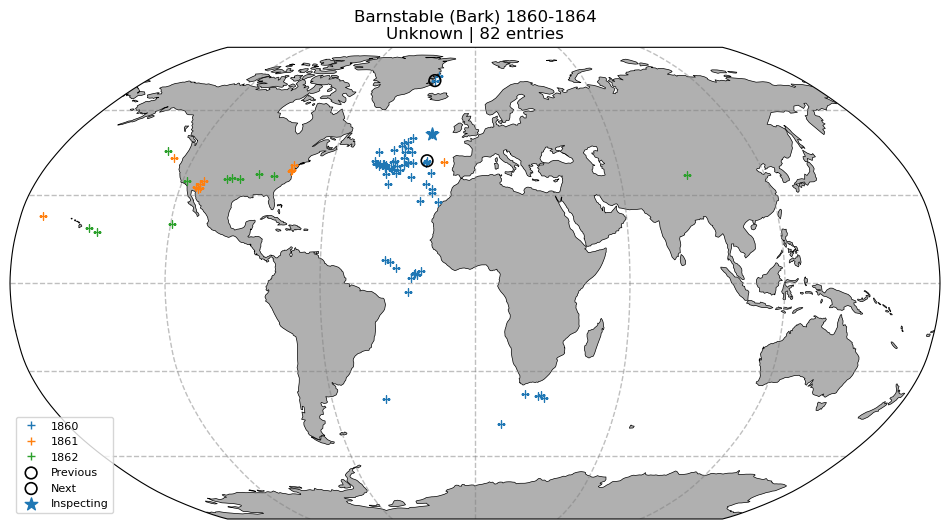

KeyboardInterrupt: Interrupted by user

In [26]:
logbook_id = flagged_books.index[1]

df = inspect_and_correct_logbook_flags(
    df,
    logbook_id=logbook_id,
    flagged_col="coord_diff",
    annotate=False,
    log_path=lpath,
    skip_list_path=unflag_list,  
    recompute_decimal_after_each=True,
    recompute_decimal_fn=lambda d: d.assign(
        Latitude_decimal=d['Latitude'].apply(dms_to_decimal),
        Longitude_decimal=d['Longitude'].apply(dms_to_decimal)
    ),
    reflag_after_each=True,
    reflag_fn=lambda d: flag_unrealistic_coord_jumps(
        d,
        time_col='Entry Date Time',
        logbook_col='LogBook ID',
        lat_col='Latitude_decimal',
        lon_col='Longitude_decimal',
        time_format='%Y-%m-%d %H:%M:%S',
        time_delta_seconds=60*60*24*2,
        latlon_delta_deg=10.0,
        lon_delta_upper_limit=320.0
    ),
)

In [113]:
import csv
outpath = os.path.join(CSV, "logbooks_flagged_cleaned.csv")
df.to_csv(outpath, index=False, encoding="utf-8", quoting=csv.QUOTE_ALL)

# Plotting the data

Lets plot all new entries that have not been visually cleaned in previous exports:

In [8]:
#Inspect trajectories of all new points to make sure flagging didnt miss anything

import pandas as pd, os, numpy as np

current_directory = os.getcwd()
Figures = os.path.join(current_directory, 'figures')
CSV = os.path.join(current_directory, 'csv_files')

# Load both exports
df_old = pd.read_csv('~/Documents/whaling_logs/20250728_export/csv_files/logentries-export-2025-08-13.csv',  low_memory=False)
df_new = pd.read_csv('~/Documents/whaling_logs/20251021_export/csv_files/logentries-export-2025-11-03.csv', low_memory=False)

df_old['Entry Date'] = pd.to_datetime(df_old['Entry Date'], errors='coerce', format='mixed')
df_new['Entry Date'] = pd.to_datetime(df_new['Entry Date'], errors='coerce', format='mixed')

df_old['Entry Date'] = df_old['Entry Date'].dt.normalize()
df_new['Entry Date'] = df_new['Entry Date'].dt.normalize()

df_old_filled = df_old.fillna('##MISSING##')
df_new_filled = df_new.fillna('##MISSING##')

# Mapping of truncated names in new df -> full names
logbook_overwrite_map = {
    "A. M. Nicholson (schooner) 190…": "A. M. Nicholson (schooner) 1909-1910",
    "Francis Allyn (Schooner) 1891-…": "Francis Allyn (Schooner) 1891-1893",
    "Governor Hopkins (Brig) 1839-1…": "Governor Hopkins (Brig) 1839-1840",
    "George Washington (Bark) 1837-…": "George Washington (Bark) 1837-1840",
    "Gideon Howland (Ship) 1838-184…": "Gideon Howland (Ship) 1838-1842",
    "Gideon Howland (ship) 1836-183…": "Gideon Howland (ship) 1836-1838",
    "Walter Irving (Schooner) 1852-…": "Walter Irving (Schooner) 1852-1853",
    "Walter Irving (Schooner) 1856-…": "Walter Irving (Schooner) 1856-1857",
    "Walter Irving (Schooner) 1855-…": "Walter Irving (Schooner) 1855-1856",
    "General Jackson (ship) 1836-18…": "General Jackson (ship) 1836-1839",
    "Walter Irving (Schooner) 1854-…": "Walter Irving (Schooner) 1854-1855",
    "Walter Irving (Schooner) 1853-…": "Walter Irving (Schooner) 1853-1854",
    #"Gage H. Phillips (Schooner) 18…": "<FILL IN FULL NAME>",  # placeholder
    "Sally Anne (ship) & Seine…": "Sally Anne (ship) & Seine (bark) 1835-1838",
    "C.C. Comstock (Schooner) 1865-…": "C.C. Comstock (Schooner) 1865-1866",
    "George Clinton (ship) 1834-183…": "George Clinton (ship) 1834-1837",
    "Charles Phelps (Ship) 1850-185…": "Charles Phelps (Ship) 1850-1853",
    "Abraham Barker (Ship) 1850-185…": "Abraham Barker (Ship) 1850-1853",
    "Henry Kneeland (ship) 1848-185…": "Henry Kneeland (ship) 1848-1851",
    "Good Return II (ship) 1833-183…": "Good Return II (ship) 1833-1834",
    "Charles and Henry (ship) 1833-…": "Charles and Henry (ship) 1833-1836",
    "Bartholomew Gosnold (Bark) 188…": "Bartholomew Gosnold (Bark) 1881-1885",
    "Leonidas (ship) Journal 1830-1…": "Leonidas (ship) Journal 1830-1833",
    "Eunice H. Adams (Brig) 1887-18…": "Eunice H. Adams (Brig) 1887-1890",
    "Governor Carver (ship) 1857-18…": "Governor Carver (ship) 1857-1859",
    "Charles Phelps (Ship) 1844-184…": "Charles Phelps (Ship) 1844-1847",
    "Clifford Wayne (ship) 1844-184…": "Clifford Wayne (ship) 1844-1847",
    "Charles Phelps (ship) 1842-184…": "Charles Phelps (ship) 1842-1844",
    "Thomas Winslow (Brig) 1846-184…": "Thomas Winslow (Brig) 1846-1847",
    "Charles W. Morgan (bark) 1911-…": "Charles W. Morgan (bark) 1911-1912",
}

# Apply the mapping to overwrite in df_new_filled
df_new_filled["LogBook ID"] = df_new_filled["LogBook ID"].replace(logbook_overwrite_map)

In [9]:
# Find new rows
new_rows = df_new_filled.merge(df_old_filled.drop_duplicates(), how='left', indicator=True)
new_rows = new_rows[new_rows['_merge'] == 'left_only'].drop(columns=['_merge'])

# Display result
print(f"{len(new_rows)} new row(s) found.")
#display(new_rows)

25085 new row(s) found.


In [10]:
# Extract unique values from the 'LogBook ID' column
logbooks_new_entries = new_rows['LogBook ID'].unique()
logbooks_new_entries = logbooks_new_entries[logbooks_new_entries != "Gage H. Phillips (Schooner) 18…"]

# Convert to a sorted list (optional)
logbooks_new_entries = sorted(logbooks_new_entries)

# Display result
print(f"{len(logbooks_new_entries)} logbooks with new entries found:")
for logbook in logbooks_new_entries:
    print(logbook)

57 logbooks with new entries found:
A. M. Nicholson (schooner) 1909-1910
Abraham Barker (Ship) 1850-1853
Alto (Bark) 1857-1862
Amazon (1856-1860)
Amethyst (Ship) 1838-1840
Awashonks (Ship) 1836-1840
Barnstable (Bark) 1860-1864
Bartholomew Gosnold (Bark) 1881-1885
C.C. Comstock (Schooner) 1865-1866
Charles Drew (Ship) 1846-1849
Charles Phelps (Ship) 1844-1847
Charles Phelps (Ship) 1850-1853
Charles Phelps (ship) 1842-1844
Charles W. Morgan (bark) 1911-1912
Charles and Henry (ship) 1833-1836
Clifford Wayne (ship) 1844-1847
Congress (Ship) 1857-1859
Eagle (Ship) 1844 -1848
Elisha Dunbar (Bark) 1854-1858
Eunice H. Adams (Brig) 1887-1890
Fenelon (Ship) 1840-1842
Francis Allyn (Schooner) 1891-1893
General Jackson (ship) 1836-1839
George Clinton (ship) 1834-1837
George Washington (Bark) 1837-1840
Gideon Howland (Ship) 1838-1842
Gideon Howland (ship) 1836-1838
Good Return II (ship) 1833-1834
Governor Carver (ship) 1857-1859
Governor Hopkins (Brig) 1839-1840
Henry Kneeland (ship) 1848-1851
Hera

In [11]:
# Get sets of unique logbook IDs
new_logbook_ids = set(df_new_filled['LogBook ID'].unique())
old_logbook_ids = set(df_old_filled['LogBook ID'].unique())

# Subtract to find newly added logbooks
newly_added_logbooks = sorted(new_logbook_ids - old_logbook_ids)

# Display the result
print(f"{len(newly_added_logbooks)} new logbooks found:")
for logbook in newly_added_logbooks:
    print(logbook)

36 new logbooks found:
A. M. Nicholson (schooner) 1909-1910
Abraham Barker (Ship) 1850-1853
Amethyst (Ship) 1838-1840
Barnstable (Bark) 1860-1864
Bartholomew Gosnold (Bark) 1881-1885
C.C. Comstock (Schooner) 1865-1866
Charles Phelps (Ship) 1844-1847
Charles Phelps (Ship) 1850-1853
Charles Phelps (ship) 1842-1844
Charles W. Morgan (bark) 1911-1912
Charles and Henry (ship) 1833-1836
Clifford Wayne (ship) 1844-1847
Eunice H. Adams (Brig) 1887-1890
Fenelon (Ship) 1840-1842
Francis Allyn (Schooner) 1891-1893
General Jackson (ship) 1836-1839
George Clinton (ship) 1834-1837
George Washington (Bark) 1837-1840
Gideon Howland (Ship) 1838-1842
Gideon Howland (ship) 1836-1838
Good Return II (ship) 1833-1834
Governor Carver (ship) 1857-1859
Governor Hopkins (Brig) 1839-1840
Henry Kneeland (ship) 1848-1851
Hibernia (Ship) 1842-1844
Jasper (Bark) 1840-1842
Leonidas (ship) Journal 1830-1833
Neptune (Ship) 1837-1839
Sally Anne (ship) & Seine (bark) 1835-1838
Scotland (Bark) 1857-1860
Thomas Winslow (Br

In [12]:
df_path = os.path.join(CSV, "logbooks_flagged_cleaned.csv")
df_flagged = pd.read_csv(df_path, low_memory=False)

# apply previously made corrections to avoid repeats 
COORD_FIXES = {
    # Amazon (1856–1860)
    125836: {"Latitude": "0 30 S"},
    125837: {"Latitude": "0 52 S"},
    125839: {"Latitude": "1 48 S"},
    125841: {"Latitude": "2 31 S"},
    125843: {"Latitude": "3 50 S"},
    125844: {"Latitude": "4 57 S"},

    # Scotland (Bark) 1857–1860
    136891: {"Longitude": "62 16 W"}, 

    # Falcon (Bark) 1865–1867
    119191: {"Latitude": "nan"},  # as given

    # Elisha Dunbar (Bark) 1854–1858
    130023: {"Longitude": "112 02 E"},

    # Lapwing (Ship) 1860–1863
    132504: {"Longitude": "108 10 W"},

    # Barnstable (Bark) 1860–1864
    134718: {"Latitude": "nan"},

    # Jasper (Bark) 1840–1842
    134162: {"Longitude": "39 57 W"},
    134163: {"Longitude": "39 40 W"},

    # Pioneer (Bark) 1858–1861
    130660: {"Longitude": "149 30 W"},

    # Young Phenix (1867–1871)
    122652: {"Longitude": "125 34 E"},

    # Amethyst (Ship) 1838–1840
    136970: {"Longitude": "172 23 E"},
    134846: {"Latitude": "38 29 N"},
}

from utils.cleaning import apply_coord_corrections
df = apply_coord_corrections(df_flagged, COORD_FIXES)

# recompute decimal degrees for adjusted row
df.loc[idx, 'Latitude_decimal']  = dms_to_decimal(df.loc[idx, 'Latitude'])
df.loc[idx, 'Longitude_decimal'] = dms_to_decimal(df.loc[idx, 'Longitude'])

NameError: name 'dms_to_decimal' is not defined

Saved figure: /home/finn.wimberly/Documents/whaling_logs/20251021_export/figures/complete_logbooks_w_new_cleaned_entries.png


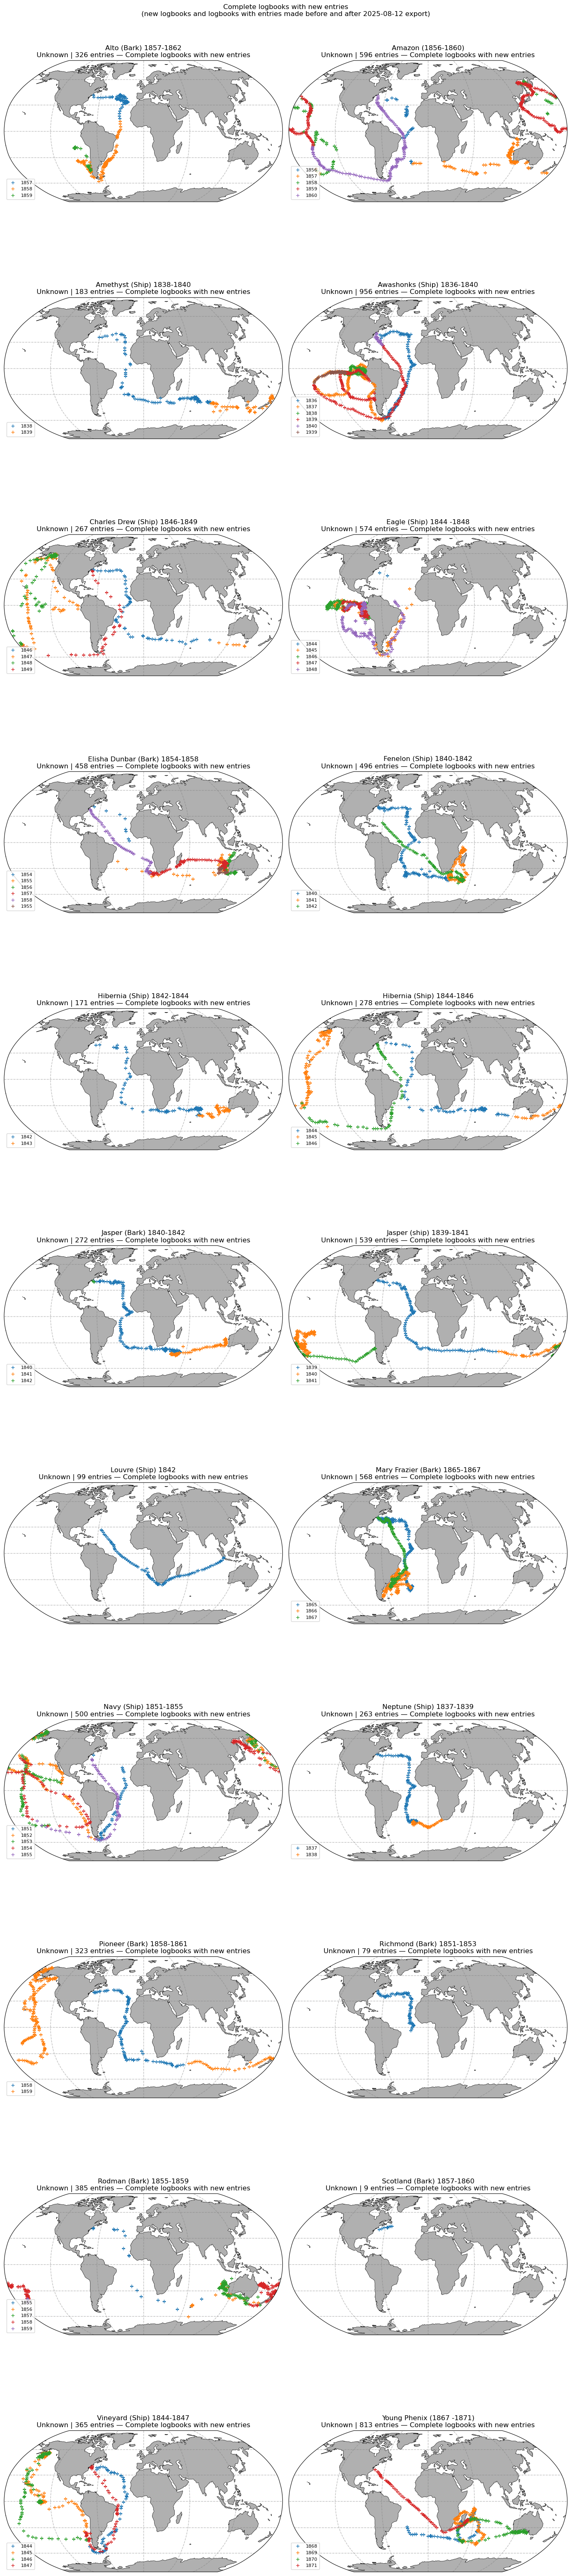

{'n_logbooks': 22, 'total_points': 8520, 'logbooks': ['Alto (Bark) 1857-1862', 'Amazon (1856-1860)', 'Amethyst (Ship) 1838-1840', 'Awashonks (Ship) 1836-1840', 'Charles Drew (Ship) 1846-1849', 'Eagle (Ship) 1844 -1848', 'Elisha Dunbar (Bark) 1854-1858', 'Fenelon (Ship) 1840-1842', 'Hibernia (Ship) 1842-1844', 'Hibernia (Ship) 1844-1846', 'Jasper (Bark) 1840-1842', 'Jasper (ship) 1839-1841', 'Louvre (Ship) 1842', 'Mary Frazier (Bark) 1865-1867', 'Navy (Ship) 1851-1855', 'Neptune (Ship) 1837-1839', 'Pioneer (Bark) 1858-1861', 'Richmond (Bark) 1851-1853', 'Rodman (Bark) 1855-1859', 'Scotland (Bark) 1857-1860', 'Vineyard (Ship) 1844-1847', 'Young Phenix (1867 -1871)'], 'scope': 'all_from_new_logbooks'}


In [39]:
from utils.cleaning import plot_new_entries

fig, axes, info = plot_new_entries(
    df_corrected=df,
    new_rows=new_rows,
    figures_dir= Figures, #set to Figures to save
    export_label="2025-08-12 export",  
    plot_scope="all_from_new_logbooks",   
    ncols=2,
    exclude_logbooks=[
        "Gage H. Phillips (Schooner) 18…", "TEST TEST HG JULY 2025"  # exclusions logbook that isn't new
    ],
)
print(info)

In [78]:
df[df['LogBook ID'] == "Amazon (1856-1860)"]

,ID,LogBook ID,Page,Entry Date,Local Time,Latitude,Latitude_decimal,Longitude,Longitude_decimal,Depth,Depth Unit,Bottom,Landmark,Ship Heading/Course,Wind Direction,WD_Bearing,Wind Speed/Force,Sea State,Cloud Cover,Weather,Ship Sightings,Miscellaneous Observations,DateTime,Entry Date Time,Depth_og,Direction,BF Value,prev_time,prev_lat,prev_lon,delta_time_s,dlat_deg,dlon_deg,coord_diff
8648,116033,Amazon (1856-1860),NaN,1856-10-22,12:00:00,35 27 N,35.450000,57 17 W,-57.283333,NaN,fathoms,NaN,NaN,E by N,NNE,22.5,strong breezes,NaN,NaN,NaN,NaN,NaN,1856-10-22 12:00:00,1856-10-22 12:00:00,NaN,NaN,6.0,NaN,NaN,NaN,NaN,NaN,NaN,False
8649,116034,Amazon (1856-1860),NaN,1856-10-23,12:00:00,35 48 N,35.800000,55 54 W,-55.900000,NaN,fathoms,NaN,NaN,E by N,N,0.0,strong breezes,NaN,passing clouds,NaN,NaN,NaN,1856-10-23 12:00:00,1856-10-23 12:00:00,NaN,NaN,6.0,1856-10-22 12:00:00,35.450000,-57.283333,86400.0,0.350000,1.383333,False
8650,116035,Amazon (1856-1860),NaN,1856-10-24,12:00:00,NaN,NaN,50 85 W,-51.416667,NaN,fathoms,NaN,NaN,E by N,W,270.0,light air,NaN,NaN,NaN,NaN,NaN,1856-10-24 12:00:00,1856-10-24 12:00:00,NaN,NaN,1.0,1856-10-23 12:00:00,35.800000,-55.900000,86400.0,NaN,4.483333,False
8651,116036,Amazon (1856-1860),NaN,1856-10-25,12:00:00,NaN,NaN,NaN,NaN,NaN,fathoms,NaN,NaN,E by N,NW,315.0,fine breases,very heavy SE,cloudy,NaN,NaN,NaN,1856-10-25 12:00:00,1856-10-25 12:00:00,NaN,NaN,45.0,1856-10-24 12:00:00,NaN,-51.416667,86400.0,NaN,NaN,False
8652,116037,Amazon (1856-1860),NaN,1856-10-26,12:00:00,37 49 N,37.816667,50 13 W,-50.216667,NaN,fathoms,NaN,NaN,E by N,WNW,292.5,fresh gales,NaN,NaN,very heavy squall,NaN,NaN,1856-10-26 12:00:00,1856-10-26 12:00:00,NaN,NaN,8.0,1856-10-25 12:00:00,NaN,NaN,86400.0,NaN,NaN,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9545,126274,Amazon (1856-1860),287,1860-06-03,12:00:00,37 06 N,37.100000,69 45 W,-69.750000,NaN,NaN,NaN,NaN,N W,WNW,292.5,strong breezes,NaN,NaN,clear,NaN,NaN,1860-06-03 12:00:00,1860-06-03 12:00:00,NaN,NaN,6.0,1860-06-02 12:00:00,35.466667,-70.700000,86400.0,1.633333,0.950000,False
9546,126275,Amazon (1856-1860),NaN,1860-06-04,12:00:00,38 40 N,38.666667,69 55 W,-69.916667,NaN,NaN,NaN,NaN,N W,WNW,292.5,strong breezes,NaN,NaN,clear,NaN,NaN,1860-06-04 12:00:00,1860-06-04 12:00:00,NaN,NaN,6.0,1860-06-03 12:00:00,37.100000,-69.750000,86400.0,1.566667,0.166667,False
9547,126276,Amazon (1856-1860),NaN,1860-06-05,12:00:00,40 20 N,40.333333,70 40 W,-70.666667,NaN,NaN,NaN,NaN,N N W,SE,135.0,fresh breezes,NaN,NaN,thick rainy,NaN,NaN,1860-06-05 12:00:00,1860-06-05 12:00:00,NaN,NaN,5.0,1860-06-04 12:00:00,38.666667,-69.916667,86400.0,1.666667,0.750000,False
9548,126277,Amazon (1856-1860),NaN,1860-06-06,12:00:00,40 44 N,40.733333,NaN,NaN,NaN,NaN,NaN,NaN,N W by N,SSE,157.5,light air,NaN,NaN,thick fog,NaN,NaN,1860-06-06 12:00:00,1860-06-06 12:00:00,NaN,NaN,1.0,1860-06-05 12:00:00,40.333333,-70.666667,86400.0,0.400000,NaN,False


Saved: /home/finn.wimberly/Documents/whaling_logs/20251021_export/figures/inspect_Amazon .png


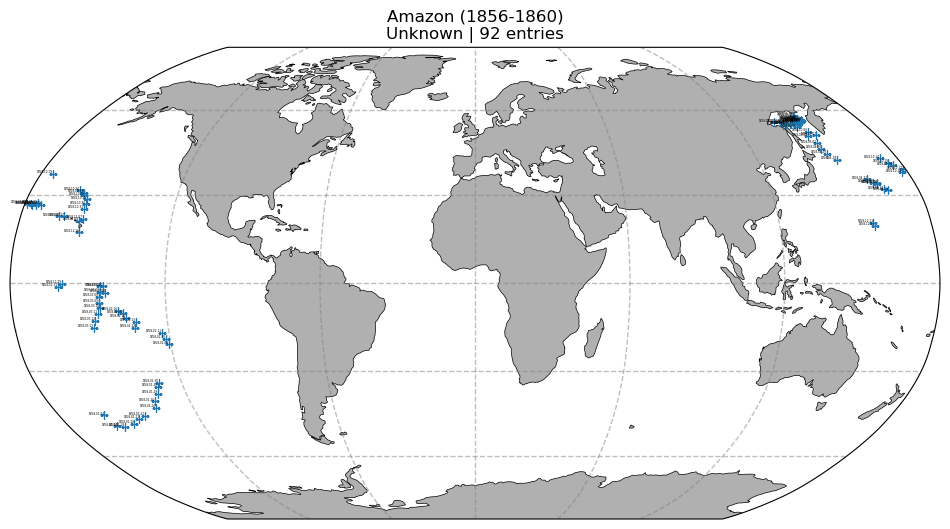

In [80]:
from utils.cleaning import plot_logbook

logbook = "Amazon (1856-1860)"
logbook_name = logbook.split('(')[0]

_ = plot_logbook(
    df, logbook,
    years=[1858],                
    annotate=True,                
    annotate_field="Entry Date",
    annotate_max=800,  
    figures_dir = Figures,
    filename=f"inspect_{logbook_name}.png",
    dpi=300,
)

In [73]:
#df[df['ID'] == 122798]
row_idx = df.index[(df['Entry Date'] == '1845-02-26') & (df['LogBook ID'] == logbook)]
idx = row_idx[0] 

from utils.cleaning import correct_coord
from utils.cleaning import dms_to_decimal

lpath = os.path.join(Files, "coord_corrections_log.txt")
correct_coord(df, idx, col = 'Latitude', log_path=lpath, force_both=False)
#correct_coord(df, idx, col = 'Longitude', log_path=lpath, force_both=False)


# recompute decimal degrees for adjusted row
df.loc[idx, 'Latitude_decimal']  = dms_to_decimal(df.loc[idx, 'Latitude'])
df.loc[idx, 'Longitude_decimal'] = dms_to_decimal(df.loc[idx, 'Longitude'])


Context for Latitude (row 114531, ID 27795):

   ID                LogBook ID Entry Date Latitude Longitude
27790 Vineyard (Ship) 1844-1847 1845-02-21   6 17 N  109 47 W
27791 Vineyard (Ship) 1844-1847 1845-02-22   6 37 N       NaN
27792 Vineyard (Ship) 1844-1847 1845-02-23   6 57 N  114 54 W
27793 Vineyard (Ship) 1844-1847 1845-02-24      NaN       NaN
27794 Vineyard (Ship) 1844-1847 1845-02-25   8 09 N       NaN
27795 Vineyard (Ship) 1844-1847 1845-02-26   8 37 S  122 30 W
27796 Vineyard (Ship) 1844-1847 1845-02-27   9 00 N       NaN
27797 Vineyard (Ship) 1844-1847 1845-02-28   9 39 N  129 09 W
27798 Vineyard (Ship) 1844-1847 1845-03-01  10 25 N       NaN
27799 Vineyard (Ship) 1844-1847 1845-03-02  11 51 N  136 00 W
27800 Vineyard (Ship) 1844-1847 1845-03-03  13 24 N  139 45 W
27801 Vineyard (Ship) 1844-1847 1845-03-04  14 52 N       NaN

Current value: 8 37 S


Enter corrected Latitude (Enter=skip, 'nan'=missing, 'both'=edit both):  8 37 N


Correction applied and logged.


#### After inspecting all new entries and making corrections, we are done. Save the cleaned dataset:

In [75]:
# Work with a copy to avoid SettingWithCopyWarning
temp_df = df.copy()

# Convert to datetime safely
temp_df['Entry Date Time'] = pd.to_datetime(temp_df['Entry Date Time'], errors='coerce')

# List of logbooks to exclude completely
exclude_logbooks = [
    'Alaska (Bark) 1880-1884',
    'Mercator(Ship) 1840-1843',
    "TEST TEST HG JULY 2025"
]

# Define rows to exclude
exclude_rows = (
    ((temp_df['LogBook ID'] == 'Howard (Ship) 1838-1841') & (temp_df['ID'] == 109907)) |
    (temp_df['LogBook ID'].isin(exclude_logbooks))  # <- NEW condition
)

# Apply filtering and save
current_directory = os.getcwd()
PKL = os.path.join(current_directory, "PKL")
os.makedirs(PKL, exist_ok=True)

df_cleaned = temp_df[~exclude_rows]
df_cleaned.to_csv(f'{CSV}/final_logbooks.csv', index=False)
df_cleaned.to_pickle(f"{PKL}/Tier1.pkl")

#### Standardize wind force classifications:

In [42]:
df = pd.read_csv(os.path.join(CSV, 'final_logbooks.csv'), low_memory=False)

unique_bf = df['BF Value'].unique()
print(unique_bf)

[ 7.  5. nan  2.  1.  4.  8.  6.  0. 23.  9. 10. 45.  3. 56. 67. 12.]


In [43]:
def map_bf(value):
    """
    Map Beaufort values:
    - Keep valid values 0–12 as-is.
    - Map ranges like 23 → 2, 45 → 4, 56 → 5, 67 → 6.
    - Leave NaN as NaN.
    """
    if pd.isna(value):
        return np.nan
    try:
        v = int(value)
        if 0 <= v <= 12:
            return v
        else:
            return int(str(v)[0])  # take the first digit for borderline cases
    except (ValueError, TypeError):
        return np.nan

df['BF Value Mapped'] = df['BF Value'].apply(map_bf)
print(sorted(df['BF Value Mapped'].dropna().unique()))

[0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 12.0]


In [44]:
df.columns

Index(['ID', 'LogBook ID', 'Page', 'Entry Date', 'Local Time', 'Latitude',
       'Latitude_decimal', 'Longitude', 'Longitude_decimal', 'Depth',
       'Depth Unit', 'Bottom', 'Landmark', 'Ship Heading/Course',
       'Wind Direction', 'WD_Bearing', 'Wind Speed/Force', 'Sea State',
       'Cloud Cover', 'Weather', 'Ship Sightings',
       'Miscellaneous Observations', 'DateTime', 'Entry Date Time', 'Depth_og',
       'Direction', 'BF Value', 'prev_time', 'prev_lat', 'prev_lon',
       'delta_time_s', 'dlat_deg', 'dlon_deg', 'coord_diff',
       'BF Value Mapped'],
      dtype='object')

In [45]:
df = df.drop(columns=['BF Value'])

df = df.rename(columns={'BF Value Mapped': 'BF Value'})

cols = list(df.columns)
insert_at = cols.index('Wind Speed/Force') + 1
cols.remove('BF Value')
cols.insert(insert_at, 'BF Value')
df = df[cols]

out_df = df.copy()
out_df['Entry Date Time'] = pd.to_datetime(out_df['Entry Date Time'], errors='coerce')

# Save as  CSV
out_base = "Tier1"  
out_df.to_csv(os.path.join(CSV, f"{out_base}.csv"), index=False)
out_df.to_pickle(os.path.join(PKL, f"{out_base}.pkl"))